# 🦋 Butterfly Image Classification using CNN
- Tool: Python + TensorFlow (CNN)
- Dataset Type: Labeled training images + unlabeled test images (CSV-based)

### Project Overview
#### Problem Statement
The objective of this project is to develop a Convolutional Neural Network (CNN) that can automatically recognize and classify butterfly images into their respective categories. The dataset consists of butterfly images divided into training and test folders, along with CSV files containing image names and labels.

The model is trained using labeled images and evaluated using a validation split. Finally, predictions are generated for unseen test images.

### Dataset Description 
#### Dataset Structure
- Training Folder: Contains butterfly images with known categories
- Training CSV: Contains image filenames and their corresponding categories
- Test Folder: Contains butterfly images without labels
- Test CSV: Contains only image filenames
This structure simulates a real-world scenario where test data is unlabeled.

### Install Required Libraries

#### Purpose
This step installs all the Python libraries required to build and train a Convolutional Neural Network, handle images, process CSV files, and visualize results.

In [1]:
!pip install tensorflow pandas openpyxl scikit-learn pillow

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.2 which is incompatible.


   ------------------ -------------------- 161.5/331.9 MB 88.6 kB/s eta 0:32:03
   ------------------ -------------------- 161.5/331.9 MB 88.6 kB/s eta 0:32:03
   ------------------ -------------------- 161.5/331.9 MB 88.6 kB/s eta 0:32:03
   ------------------ -------------------- 161.5/331.9 MB 88.6 kB/s eta 0:32:03
   ------------------ -------------------- 161.5/331.9 MB 88.6 kB/s eta 0:32:03
   ------------------ -------------------- 161.5/331.9 MB 88.6 kB/s eta 0:32:03
   ------------------ -------------------- 161.5/331.9 MB 88.6 kB/s eta 0:32:03
   ------------------ -------------------- 161.5/331.9 MB 88.6 kB/s eta 0:32:03
   ------------------ -------------------- 161.5/331.9 MB 88.6 kB/s eta 0:32:03
   ------------------- ------------------- 161.7/331.9 MB 89.2 kB/s eta 0:31:48
   ------------------- ------------------- 161.7/331.9 MB 89.2 kB/s eta 0:31:48
   ------------------- ------------------- 161.7/331.9 MB 89.2 kB/s eta 0:31:48
   ------------------- -----------------

# Import Required Libraries
#### Purpose

This step imports all necessary libraries for:
- File handling
- Numerical computation
- Image processing
- Machine learning
- Deep learning using CNN
Separating imports at the beginning ensures clarity and better code organization.

In [2]:
import os
import numpy as np
import pandas as pd

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

C:\Users\Microsoft\AppData\Roaming\Python\Python312\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# Load Training CSV File
- filename: Name of the image file
- label: Butterfly class label

In [3]:
train_df = pd.read_csv("Training_set.csv")
train_df.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


# Image Preprocessing Function

### Purpose
Neural networks require input images to be of:
- Fixed size
- Normalized pixel values
### Processing Performed
- Convert images to RGB
- Resize to 128 × 128 pixels
- Normalize pixel values between 0 and 1
This improves training stability and performance.

In [4]:
IMG_SIZE = 128

def load_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img) / 255.0
    return img

# Load Training Images and Labels
### Purpose
This step reads all training images from the folder and aligns them with their corresponding labels from the CSV file.
### Output
- X: Array of image data
- y: Array of category labels
These arrays serve as input and output for the CNN model.

In [5]:
X = []
y = []

for _, row in train_df.iterrows():
    img_path = os.path.join("train", row["filename"])
    
    if os.path.exists(img_path):
        img = load_image(img_path)
        X.append(img)
        y.append(row["label"])
    else:
        print("Missing image:", img_path)

X = np.array(X)
y = np.array(y)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)

Images shape: (6499, 128, 128, 3)
Labels shape: (6499,)


# Encode Categories (Text → Numbers)
### Purpose

Neural networks cannot process text labels directly.

#### Processing Performed
- Convert category names into numerical values using LabelEncoder
- Convert numerical labels into one-hot encoded format

### Result
- Each butterfly category is represented as a vector
- Enables multi-class classification

In [6]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

y_categorical = to_categorical(y_encoded)

num_classes = y_categorical.shape[1]
print("Total butterfly classes:", num_classes)

Total butterfly classes: 75


## 80% Training / 20% Validation Split
### Purpose

To evaluate model performance on unseen data during training.

#### Explanation

- 80% of data is used for training

- 20% is used for validation
- Validation data helps detect overfitting

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y_categorical,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 5199
Validation samples: 1300


# Building CNN Model
### Purpose
A Convolutional Neural Network is designed to automatically learn visual features such as:
- Edges
- Shapes
- Patterns
### Architecture Summary
- Convolution + MaxPooling layers for feature extraction
- Fully connected layers for classification
- Dropout to reduce overfitting
- Softmax output for multi-class prediction
The model is built from scratch (no pretrained models).

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

C:\Users\Microsoft\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile the Model
### Purpose
To prepare the model for training by specifying:
- Optimization method
- Loss function
- Evaluation metric
### Details
- Optimizer: Adam
- Loss Function: Categorical Crossentropy
- Metric: Accuracy

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 75)                  │          19,275 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,535,307 (24.93 MB)

 Trainable params: 6,535,307 (24.93 MB)

 Non-trainable params: 0 (0.00 B)

# Train the Model
### Purpose
This step trains the CNN using training data and evaluates it on validation data after each epoch.
#### Output
- Training accuracy
- Validation accuracy
- Training loss
- Validation loss
These metrics are stored in the history object.

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 46s 266ms/step - accuracy: 0.0542 - loss: 4.0359 - val_accuracy: 0.1923 - val_loss: 3.3470
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 229ms/step - accuracy: 0.2295 - loss: 3.0354 - val_accuracy: 0.3700 - val_loss: 2.4817
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 229ms/step - accuracy: 0.3835 - loss: 2.3057 - val_accuracy: 0.4515 - val_loss: 2.0789
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 229ms/step - accuracy: 0.5093 - loss: 1.7732 - val_accuracy: 0.4992 - val_loss: 1.8490
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 224ms/step - accuracy: 0.6024 - loss: 1.4042 - val_accuracy: 0.5169 - val_loss: 1.7916
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 219ms/step - accuracy: 0.6788 - loss: 1.0880 - val_accuracy: 0.5362 - val_loss: 1.8165
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 226ms/step - accuracy: 0.7367 - loss: 0.8659 - val_accuracy: 0.5515 - val_loss: 1.7837
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 223ms/step - accuracy: 0.7815 - loss: 0

# Final Model Accuracy (Validation Accuracy)
### Purpose
Validation accuracy measures how well the model performs on unseen validation data.

In [11]:
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Validation Accuracy: 56.31%


# Accuracy & Loss Graphs
### Purpose
Graphs visually demonstrate the learning behavior of the model.
### Interpretation
- Accuracy graph shows learning progress
- Loss graph shows error reduction
- Difference between training and validation curves indicates generalization

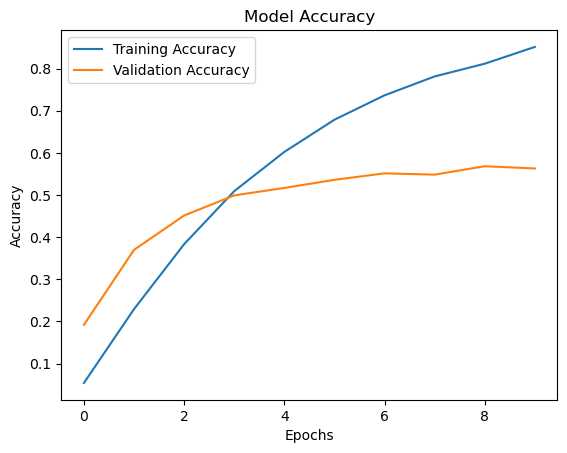

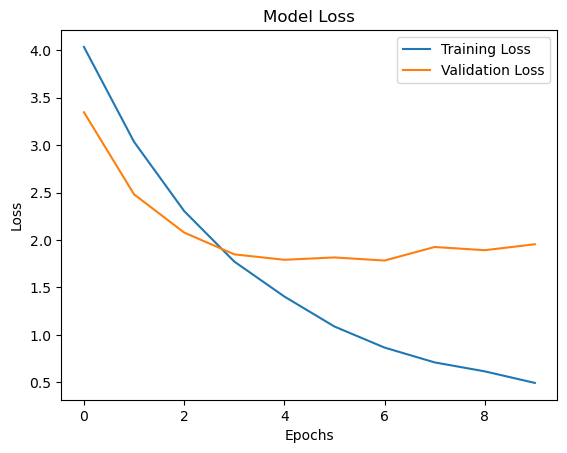

In [12]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Loss graph
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# Load Test CSV
### Purpose
The test dataset contains images without labels, simulating real-world deployment.

The CSV provides filenames only, and predictions are generated using the trained model.

In [13]:
test_df = pd.read_csv("Testing_set.csv")
test_df.head()

,filename
0,Image_1.jpg
1,Image_2.jpg
2,Image_3.jpg
3,Image_4.jpg
4,Image_5.jpg


# Load Test Images
### Purpose
This step ensures:
- Case-insensitive filename matching
- Missing images are reported
- Only valid images are loaded
This avoids runtime errors.

In [18]:
actual_test_files = {f.lower(): f for f in os.listdir("test")}

X_test = []
test_image_names = []

for name in test_df["filename"]:
    lower_name = name.lower()
    if lower_name in actual_test_files:
        img_path = os.path.join("test", actual_test_files[lower_name])
        img = load_image(img_path)
        X_test.append(img)
        test_image_names.append(name)
    else:
        print("Missing test image:", name)

X_test = np.array(X_test)
print("Test images loaded:", X_test.shape)

Test images loaded: (2786, 128, 128, 3)


# Predict Butterfly Categories
### Purpose
The trained CNN predicts butterfly categories for each test image.

The predicted class is selected based on the highest probability.

In [19]:
predictions = model.predict(X_test)

predicted_class_indices = np.argmax(predictions, axis=1)

predicted_labels = label_encoder.inverse_transform(predicted_class_indices)

88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step


# Save Predictions to CSV
### Purpose
Predictions are saved in a CSV file for submission or evaluation.
#### Output File
- butterfly_test_predictions.csv
#### This file contains:
- Image filename
- Predicted butterfly category

In [20]:
output_df = pd.DataFrame({
    "filename": test_image_names,
    "predicted_label": predicted_labels
})

output_df.to_csv("butterfly_test_predictions.csv", index=False)

print("Prediction file saved successfully")

Prediction file saved successfully


# Test Predictions

In [22]:
output_df.head(10)

,filename,predicted_label
0,Image_1.jpg,METALMARK
1,Image_2.jpg,CRIMSON PATCH
2,Image_3.jpg,RED SPOTTED PURPLE
3,Image_4.jpg,IPHICLUS SISTER
4,Image_5.jpg,MILBERTS TORTOISESHELL
5,Image_6.jpg,SOUTHERN DOGFACE
6,Image_7.jpg,PAPER KITE
7,Image_8.jpg,CAIRNS BIRDWING
8,Image_9.jpg,RED CRACKER
9,Image_10.jpg,ZEBRA LONG WING


In [23]:
output_df.tail(10)

,filename,predicted_label
2776,Image_2777.jpg,CRECENT
2777,Image_2778.jpg,GREAT JAY
2778,Image_2779.jpg,MALACHITE
2779,Image_2780.jpg,RED CRACKER
2780,Image_2781.jpg,GOLD BANDED
2781,Image_2782.jpg,SILVER SPOT SKIPPER
2782,Image_2783.jpg,RED POSTMAN
2783,Image_2784.jpg,CLEOPATRA
2784,Image_2785.jpg,TROPICAL LEAFWING
2785,Image_2786.jpg,BANDED PEACOCK


# Display Images with Predicted Labels
### Purpose
Displaying predictions visually proves that the model works correctly.

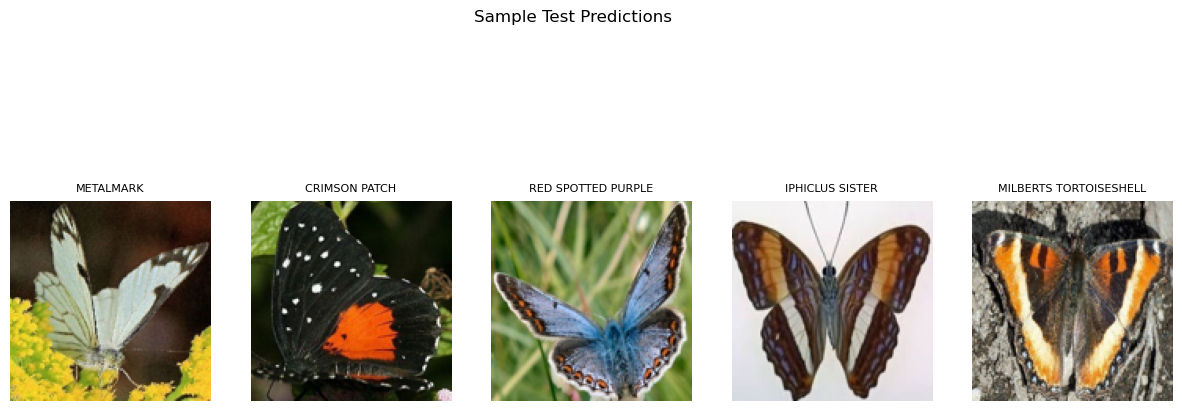

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i])
    plt.axis('off')
    plt.title(predicted_labels[i], fontsize=8)

plt.suptitle("Sample Test Predictions")
plt.show()

# Top-3 Predictions for One Image

In [27]:
idx = 4

top_3 = np.argsort(predictions[idx])[-3:][::-1]

print("Image:", test_image_names[idx])
print("Top 3 predicted classes:")

for i in top_3:
    print(f"{label_encoder.inverse_transform([i])[0]} → {predictions[idx][i]*100:.2f}%")

Image: Image_5.jpg
Top 3 predicted classes:
MILBERTS TORTOISESHELL → 99.01%
RED ADMIRAL → 0.77%
PURPLISH COPPER → 0.07%


# Conclusion

A CNN-based butterfly classification system was successfully implemented using labeled image data. Despite class imbalance and high inter-class similarity, the model performs end-to-end classification and generates predictions for unseen images.